In [ ]:
import pandas as pd

url = "https://data.cityofnewyork.us/resource/jz4z-kudi.csv"

# Check total row count first to make sure all rows made it. There are 21M+
count_url = "https://data.cityofnewyork.us/resource/jz4z-kudi.csv?$select=count(*)"
print(pd.read_csv(count_url))

      count
0  21625705


In [ ]:
import pandas as pd

url = "https://data.cityofnewyork.us/resource/jz4z-kudi.csv"

#21M rows was too large
#downgraded to 1M rows instead
#told pandas low_memory=False because earlier, without it, I got a warning about numbers in one chunk of data and text in another for the same column;
#with the addition of low_memory=False, pandas can read the whole file at once before deciding what type each column is

df = pd.read_csv(f"{url}?$limit=1000000&$offset=0", low_memory=False)
print(df.shape)
df.head()

In [ ]:
#Research q: How do violation outcomes differ by issuing agency?
#Furthermore, how does knowing which agencies have higher/lower dismissal rates in OATH hearings suggest about the quality and fairness of enforcement of fines and such?
#Here's what I found (the pattern in the data)
#Here's why it might be happening and why it's important (interpretation)
#Who should care about this? OATH, city government, the public, etc.

In [ ]:
#find missing values
print(df.isnull().sum())

In [ ]:
#check what hearing results are available in the dataset by counting unique results
print(df['hearing_result'].value_counts(dropna=False))

#there is DEFAULTED and DEFAULT so I know to clean up the data already
#default/no appearance is also the same thing.
#there are some with pending outcomes so I'm going to drop those to focus on the ones that already have results

In [ ]:
#count unique values for agencies too
print(df['issuing_agency'].value_counts(dropna=False))
#there are many sanitation complaints

In [ ]:
#dropping rows where either key analysis column is blank
df_clean = df.dropna(subset=['hearing_result', 'issuing_agency'])

In [ ]:
#standardize capitalization
df_clean['hearing_result'] = df_clean['hearing_result'].str.upper().str.strip()
df_clean['issuing_agency'] = df_clean['issuing_agency'].str.upper().str.strip()

In [74]:
#data cleaning continued
df_clean['hearing_result'] = df_clean['hearing_result'].replace({
    'DEFAULT': 'DEFAULTED',
    'DEFAULT/ NO APPEARANCE': 'DEFAULTED'
})

#merging the IN VIOLATION results that make sense to merge
df_clean['hearing_result'] = df_clean['hearing_result'].replace({
    'ADMIT IN-VIO': 'IN VIOLATION',
    'POP IN-VIOL': 'IN VIOLATION',
    'SETTL IN-VIO': 'IN VIOLATION',
    'SUSTAINED': 'IN VIOLATION'
})

#merging all DISMISSED results
df_clean['hearing_result'] = df_clean['hearing_result'].replace({
    'DISMISSED - FAILURE TO PROSECUTE': 'DISMISSED',
    'DISMISSED NO VIOLATION/ON THE MERITS': 'DISMISSED',
    'DISMISSED DEFECTIVE SERVICE': 'DISMISSED',
    'DISMISSED - NO PRIMA FACIE CASE': 'DISMISSED',
    'DISMISSED DEFECTIVE SUMMONS/CHARGE (DEFECTIVE ON ITS FACE)': 'DISMISSED',
    'DISMISSED - WRONG PARTY NAMED': 'DISMISSED',
    'DISMISSED NO JURISDICTION': 'DISMISSED',
    'DISMISSED - SUCCESSFULLY DISPUTED OWNERSHIP': 'DISMISSED'
})

#keeping only final outcomes
final_outcomes = ['IN VIOLATION', 'DISMISSED', 'DEFAULTED']
df_clean = df_clean[df_clean['hearing_result'].isin(final_outcomes)]

#dropping agencies with fewer than 100 total cases since a lot of them only have 1 off cases
agency_counts = df_clean['issuing_agency'].value_counts()
big_agencies = agency_counts[agency_counts >= 100].index
df_clean = df_clean[df_clean['issuing_agency'].isin(big_agencies)]

#checking and printing what's left
print(df_clean['hearing_result'].value_counts())
print(f"\nNumber of agencies remaining: {df_clean['issuing_agency'].nunique()}")
print(f"Total rows remaining: {len(df_clean)}")


hearing_result
DEFAULTED       308723
IN VIOLATION    113527
DISMISSED        50815
Name: count, dtype: int64

Number of agencies remaining: 42
Total rows remaining: 473065


308,757 people defaulted on the case which means they didn't show up to the hearing.

In [73]:
#I wanted to build a heatmap

import seaborn as sns
import matplotlib.pyplot as plt

#count cases by agency and outcome
heatmap_df = df_clean.groupby(['issuing_agency', 'hearing_result']).size().reset_index(name='count')

#technique to pivot so one agency=a row and the outcome=a column
heatmap_pivot = heatmap_df.pivot(index='issuing_agency', columns='hearing_result', values='count').fillna(0)

#I had forgotten that some agencies are much much bigger than others so using percentages should make it fairer
heatmap_percent = heatmap_pivot.div(heatmap_pivot.sum(axis=1), axis=0) * 100

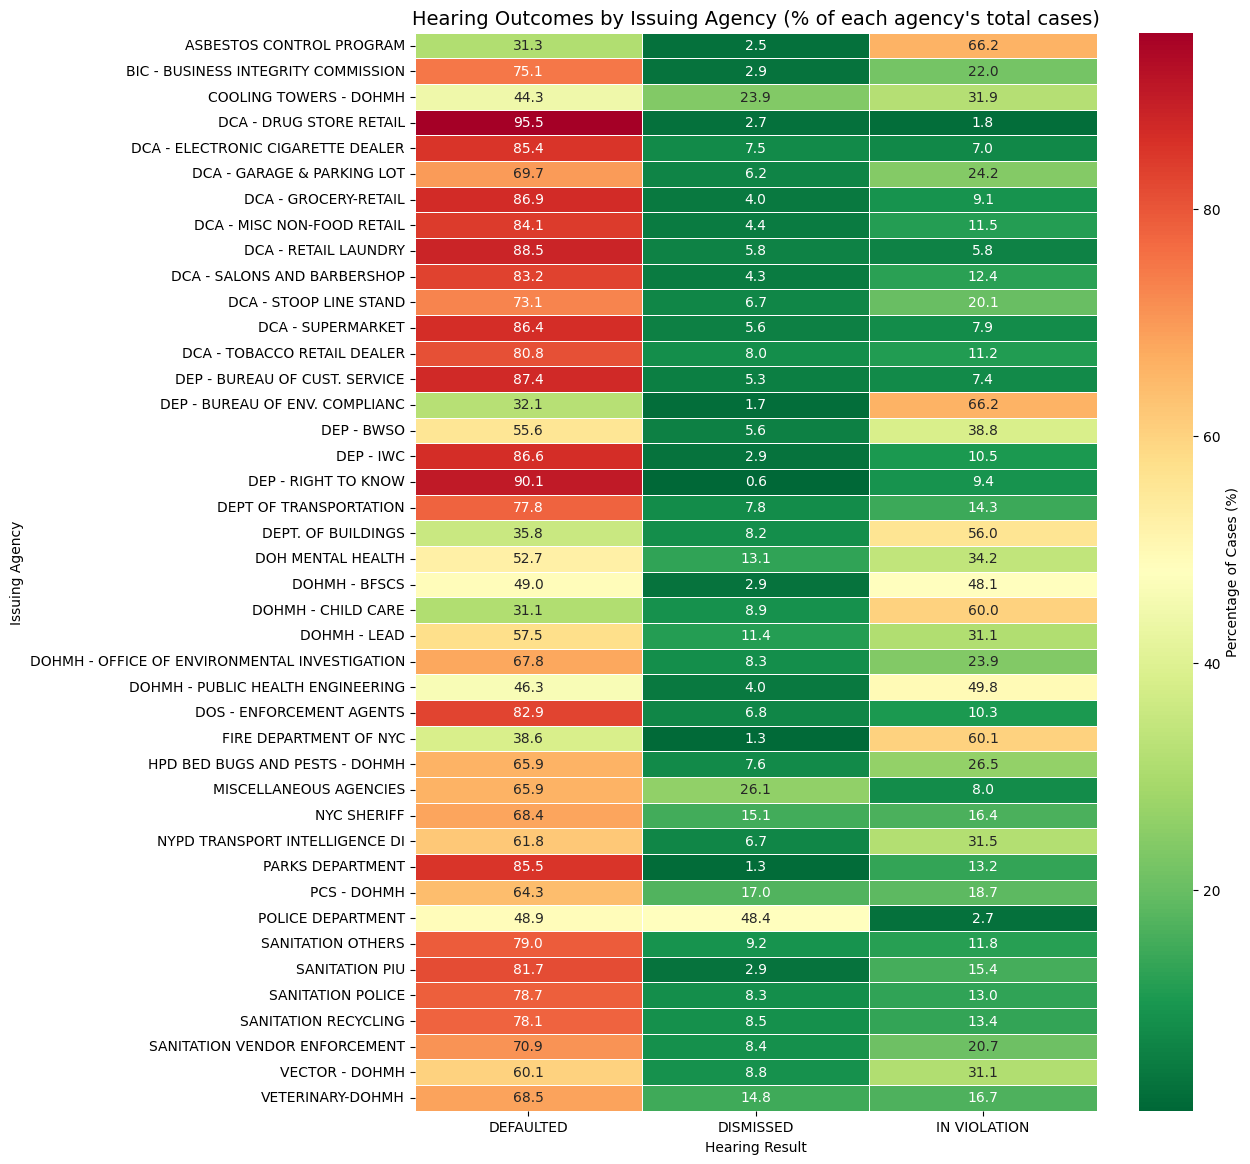

In [72]:
#heatmap
plt.figure(figsize=(11, 14))

sns.heatmap(
    heatmap_percent,
    annot=True,          #shows the actual % numbers inside each cell
    fmt='.1f',           #rounds to 1 decimal place
    cmap='RdYlGn_r',     #red = high, green = low
    linewidths=0.5,      #cell lines to separate
    cbar_kws={'label': 'Percentage of Cases (%)'}
)

plt.title('Hearing Outcomes by Issuing Agency (% of each agency\'s total cases)', fontsize=14)
plt.xlabel('Hearing Result')
plt.ylabel('Issuing Agency')
plt.show()


I see that most cases in orange to red starting at 60% are defaulted at hearing. That means the respondants are not showing up at hearing. Their judgements/hearing results probably lead to additional fines on top of their original violation # amounts.

The agencies that are most interesting to me is NYPD and the Asbestos control program. For the (NYPD) POLICE DEPARTMENT (48.4% dismissed), nearly half of NYPD cases get thrown out/DISMISSED, which is striking and raises real questions about the quality of their summons.

For the Asbestos program, 31.3% of people who had violations defaulted or didn't show up to hearing, which likely means they knew they were at fault. Since it had 66.2% people who violated the asbestos code, I'd say that this agency is very stringent about giving out fines to those who violate the code. That goes to par for most environmental agencies. If I didn't see the data, I would have predicted that enforcement would be tight anyways because building have to be up to code for people to live and work in buildings.

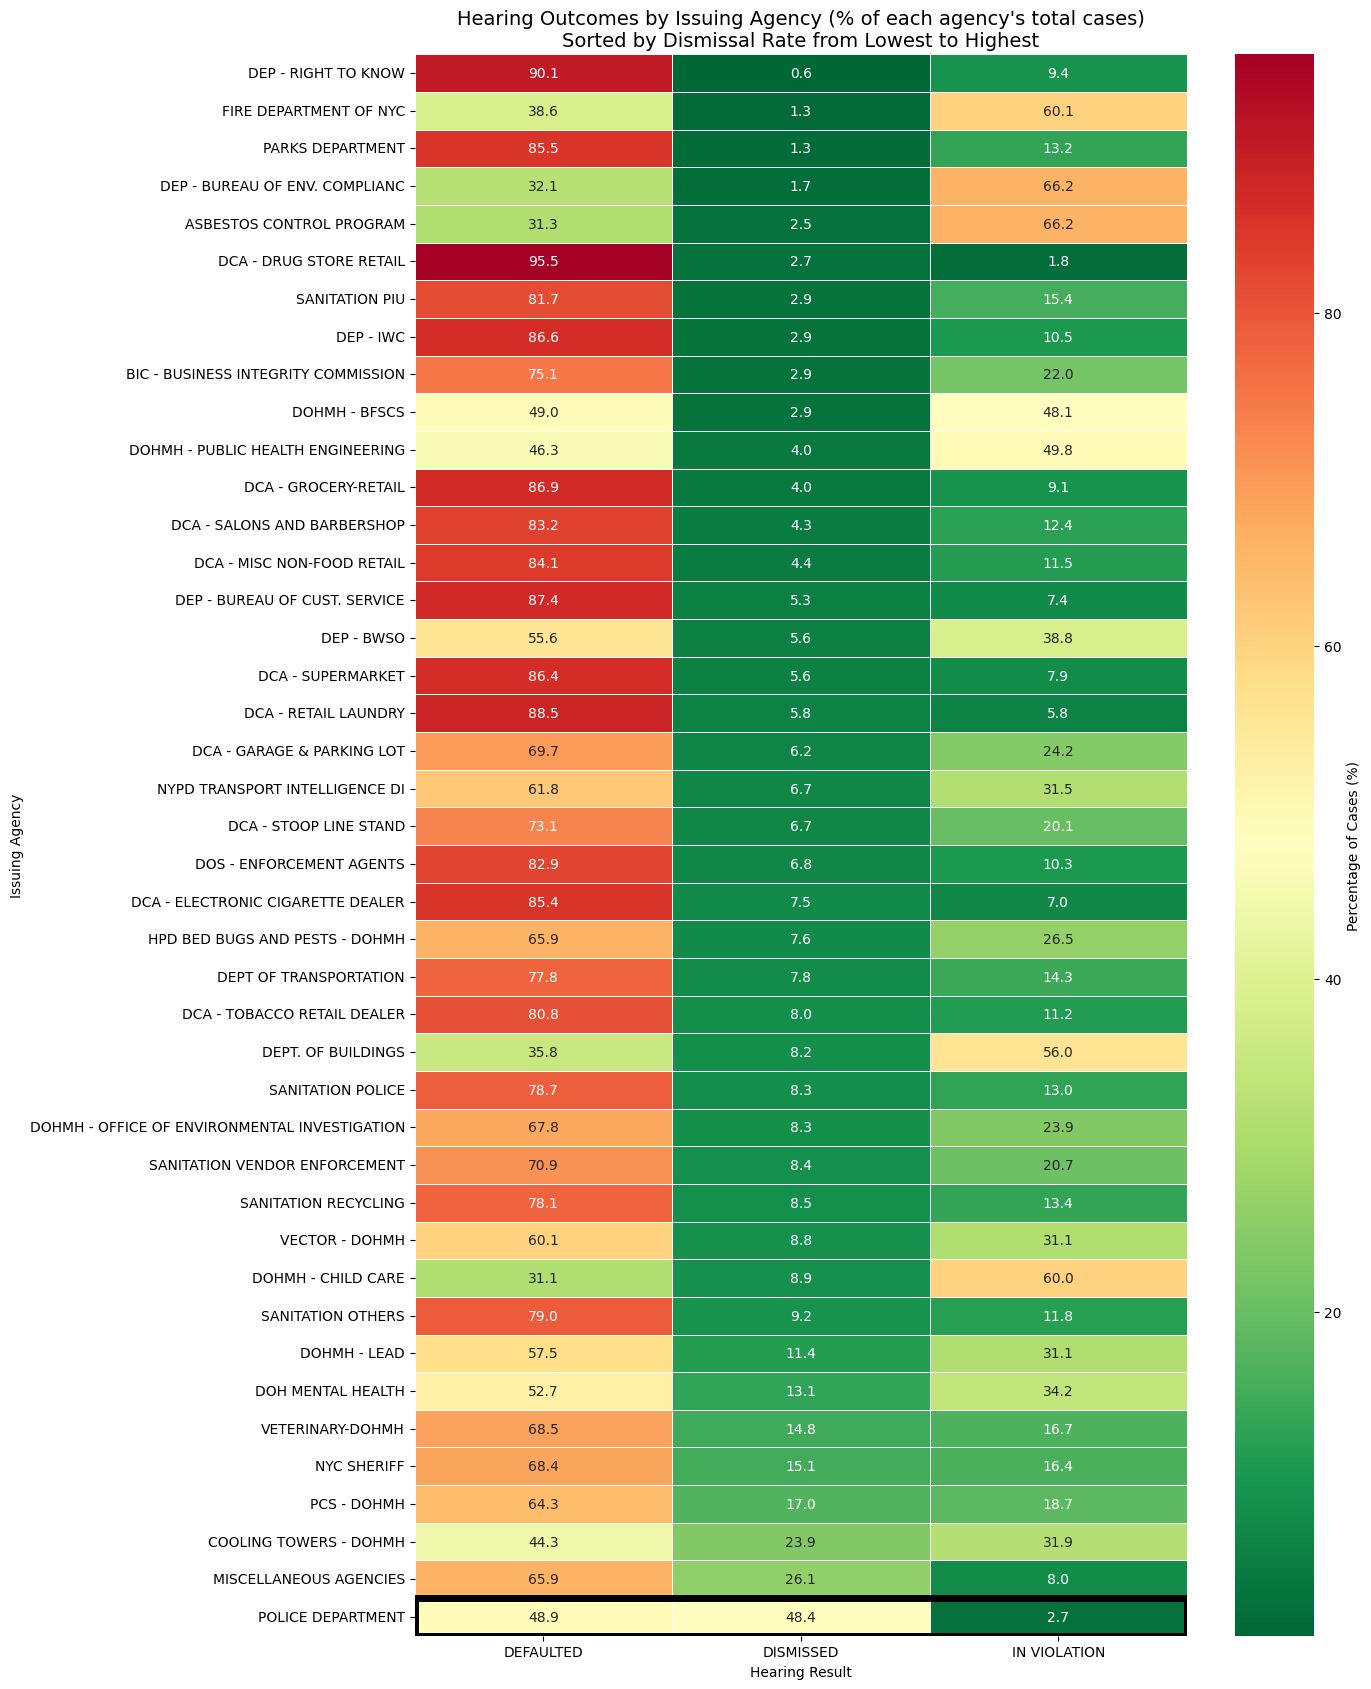

In [75]:
#reworking heatmap
import seaborn as sns
import matplotlib.pyplot as plt

#Sort agencies by dismissal rate (with highest dismissed rate at the top)
heatmap_pct_sorted = heatmap_percent.sort_values('DISMISSED', ascending=True)

plt.figure(figsize=(14, 17))

ax = sns.heatmap(
    heatmap_pct_sorted,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn_r', #colors
    linewidths=0.5,
    cbar_kws={'label': 'Percentage of Cases (%)'}
)

#highlighting the NYPD row
nypd_row = list(heatmap_pct_sorted.index).index('POLICE DEPARTMENT')

ax.add_patch(plt.Rectangle(
    (0, nypd_row),        #starting position (column 0, nypd row)
    3,                     # width to cover all 3 columns
    1,                     #height for 1 row
    fill=False,            #don't fill it, just the border
    edgecolor='black',      #border color to stand out
    lw=5                   #thickness of the border
))

plt.title('Hearing Outcomes by Issuing Agency (% of each agency\'s total cases)\nSorted by Dismissal Rate from Lowest to Highest', fontsize=14)
plt.xlabel('Hearing Result')
plt.ylabel('Issuing Agency')
plt.tight_layout()
plt.show()

In [68]:
#look at NYPD #s
#of the cases that weren't defaulted, what % was dismissed?
nypd_dismissed = 48.4
nypd_in_violation = 2.7

#out of the non-defaulted cases only
contested_by_people = nypd_dismissed + nypd_in_violation  # = 51.1%
dismissed_of_contested = nypd_dismissed / contested_by_people * 100

print(f"{dismissed_of_contested:.1f}% of contested NYPD cases were dismissed")

94.7% of contested NYPD cases were dismissed


Bringing attention to the agencies like the police department which are low in violations, high in dismissals. Nearly half are thrown out in front of a judge which means that the NYPD are not building strong cases. The NYPD's low in violation rate is driven by dismissals, not defaults. Almost nobody contests NYPD tickets (48.9% don't show up/defaults), but for the small share that do show up and get a hearing, 94.7% of those cases get dismissed by a judge.

Multiple reasons for high dismissals off the top of my head:
1) There is not enough evidence.
2) inspectors who fine people are not trained well or are inconsistent in their reasonings for issuing a violation/fine.
3) there may be biases/unfairness in issuing summons.
4) might be form/paperwork mixups.

High dismissals also mean:
1) taxpayers' money are being wasted on weak cases that don't have any standing.
2) people might be wrongly ticketed.
3) if people are being wrongly ticketed, they have to waste time to go fight for themselves at hearing, losing time at work.
4) cases like these are clogging the hearings dockets systems with bad cases that don't go anywhere when in fact, OATH could focus on other cases.

In [76]:
#descriptive stats
print("OVERALL DATASET SUMMARY")
print(f"Total cases: {len(df_clean):,}")
print(f"Total agencies: {df_clean['issuing_agency'].nunique()}")
print(f"Date range: {df['violation_date'].min()} to {df['violation_date'].max()}")
#the people who inputted the violations/tickets into the system did not date them correctly
#since I didn't focus on time, I just left the dates

OVERALL DATASET SUMMARY
Total cases: 473,065
Total agencies: 42
Date range: 2025-03-04T00:00:00.000 to 5201-05-12T00:00:00.000


In [77]:
#outcomes across ALL agencies equalling the total cases 473,116
print("OVERALL OUTCOME BREAKDOWN")
outcome_counts = df_clean['hearing_result'].value_counts()
outcome_pct = df_clean['hearing_result'].value_counts(normalize=True) * 100

for outcome in outcome_counts.index:
    print(f"{outcome}: {outcome_counts[outcome]:,} cases ({outcome_pct[outcome]:.1f}%)")

OVERALL OUTCOME BREAKDOWN
DEFAULTED: 308,723 cases (65.3%)
IN VIOLATION: 113,527 cases (24.0%)
DISMISSED: 50,815 cases (10.7%)


In [78]:
#Avg dismissal rate across all agencies
print("DISMISSAL RATE STATISTICS")
print(f"Average dismissal rate across all agencies: {heatmap_percent['DISMISSED'].mean():.1f}%")
print(f"Highest dismissal rate: {heatmap_percent['DISMISSED'].max():.1f}% ({heatmap_percent['DISMISSED'].idxmax()})")
print(f"Lowest dismissal rate: {heatmap_percent['DISMISSED'].min():.1f}% ({heatmap_percent['DISMISSED'].idxmin()})")

#DEP Right to Know is a environmental community program - requires facilities to report hazardous substances to ensure public safety and environmental protection.

DISMISSAL RATE STATISTICS
Average dismissal rate across all agencies: 8.5%
Highest dismissal rate: 48.4% (POLICE DEPARTMENT)
Lowest dismissal rate: 0.6% (DEP - RIGHT TO KNOW)


In [79]:
#NYPD specific
print("NYPD SPECIFIC STATS")
nypd_cases = df_clean[df_clean['issuing_agency'] == 'POLICE DEPARTMENT']
print(f"Total NYPD cases: {len(nypd_cases):,}")

# of cases that weren't defaulted, how many were dismissed?
nypd_contested = nypd_cases[nypd_cases['hearing_result'] != 'DEFAULTED']
nypd_dismissed_of_contested = (nypd_contested['hearing_result'] == 'DISMISSED').sum() / len(nypd_contested) * 100
print(f"NYPD contested cases (non-defaulted where the respondant showed up at hearing): {len(nypd_contested):,}")
print(f"Of those, the dismissal rate was: {nypd_dismissed_of_contested:.1f}%")

#How many of the total 34,256 NYPD cases were dismissed?
nypd_total = len(nypd_cases)
nypd_dismissed_count = (nypd_cases['hearing_result'] == 'DISMISSED').sum()
nypd_dismissed_pct = nypd_dismissed_count / nypd_total * 100

print(f"Dismissed cases: {nypd_dismissed_count:,}")
print(f"That is {nypd_dismissed_pct:.1f}% of all NYPD cases")

NYPD SPECIFIC STATS
Total NYPD cases: 34,230
NYPD contested cases (non-defaulted where the respondant showed up at hearing): 17,482
Of those, the dismissal rate was: 94.7%
Dismissed cases: 16,557
That is 48.4% of all NYPD cases


In [90]:
#Comparing NYPD dismissal rate to the citywide average
print("NYPD VS CITYWIDE COMPARISON")
citywide_avg = heatmap_percent['DISMISSED'].mean()
nypd_dismissed = heatmap_percent.loc['POLICE DEPARTMENT', 'DISMISSED']
print(f"Citywide average dismissal rate: {citywide_avg:.1f}%")
print(f"NYPD dismissal rate: {nypd_dismissed:.1f}%")
#48.4 / 8.5% = 5.69 -> 5.7
print(f"NYPD is {nypd_dismissed - citywide_avg:.1f} % points above the citywide average using (nypd_dismissed - citywide_avg) or 5.7x as much as the citywide average using (NYPD dismissal rate / citywide average dismissal rate)")

NYPD VS CITYWIDE COMPARISON
Citywide average dismissal rate: 8.5%
NYPD dismissal rate: 48.4%
NYPD is 39.9 % points above the citywide average using (nypd_dismissed - citywide_avg) or 5.7x as much as the citywide average using (NYPD dismissal rate / citywide average dismissal rate)


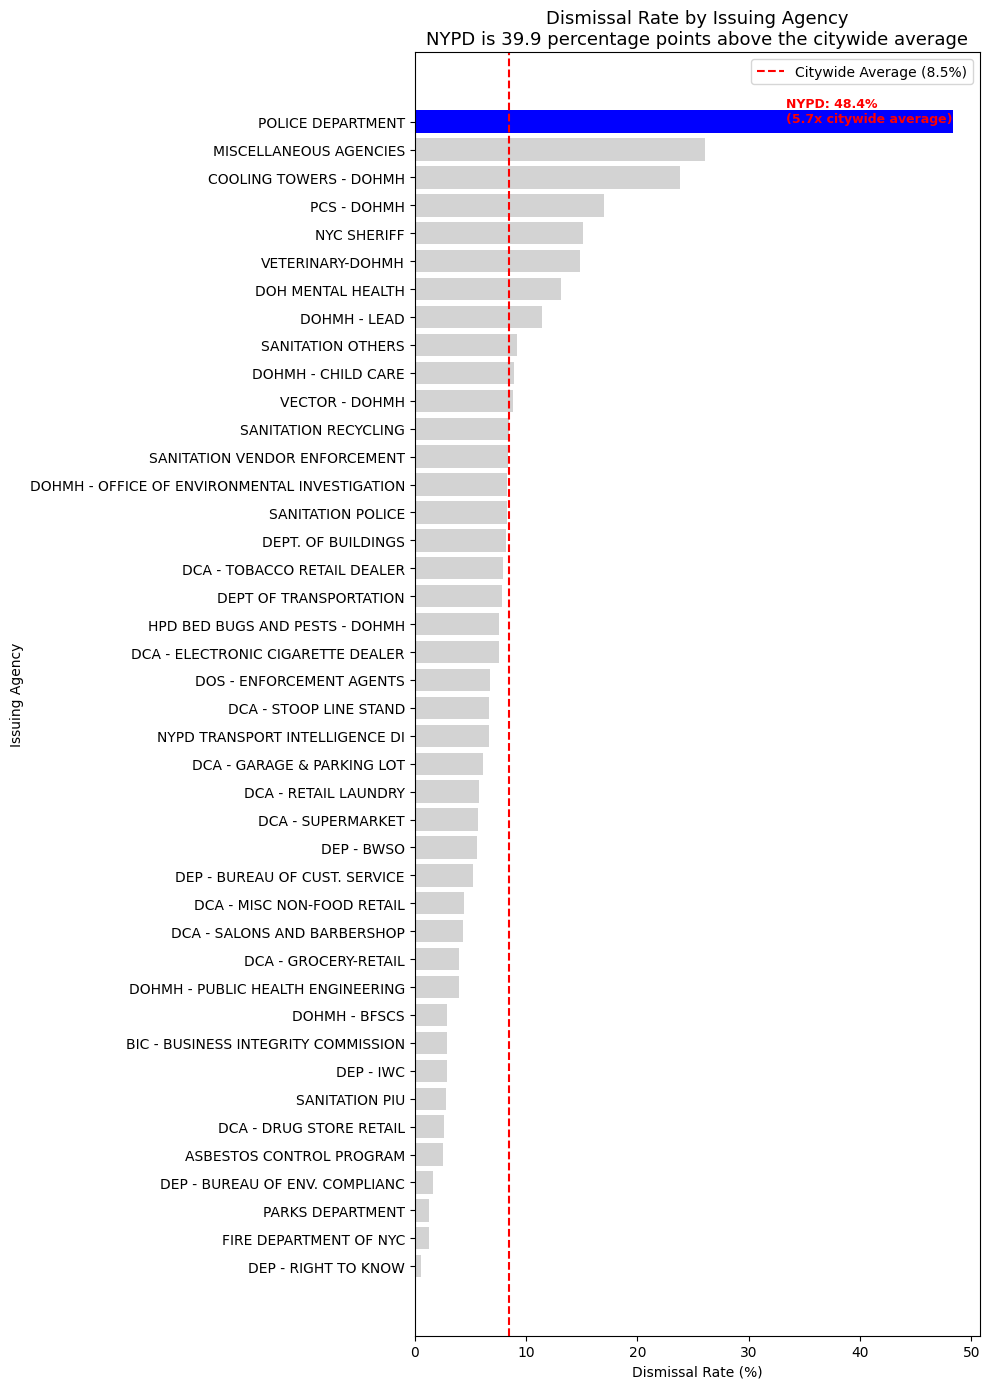

In [87]:
#found a similar chart to get the code to get a dotted line to show on the chart where the average is

import matplotlib.pyplot as plt

#dismissal rate for each agency sorted from highest to lowest
dismissal_rates = heatmap_percent['DISMISSED'].sort_values(ascending=True)

#make NYPD blue and everyone else gray
colors = ['blue' if agency == 'POLICE DEPARTMENT' else 'lightgray'
          for agency in dismissal_rates.index]

fig, ax = plt.subplots(figsize=(10, 14))
ax.barh(dismissal_rates.index, dismissal_rates.values, color=colors)

nypd_value = dismissal_rates['POLICE DEPARTMENT']
ax.annotate(f'NYPD: {nypd_value:.1f}%\n(5.7x citywide average)',
            xy=(nypd_value, 'POLICE DEPARTMENT'),
            xytext=(nypd_value - 15, 'POLICE DEPARTMENT'),
            fontsize=9,
            color='red',
            fontweight='bold')

citywide_avg = heatmap_percent['DISMISSED'].mean()
ax.axvline(x=citywide_avg, color='red', linestyle='--', linewidth=1.5, label=f'Citywide Average ({citywide_avg:.1f}%)')

ax.set_title('Dismissal Rate by Issuing Agency\nNYPD is 39.9 percentage points above the citywide average', fontsize=13)
ax.set_xlabel('Dismissal Rate (%)')
ax.set_ylabel('Issuing Agency')
ax.legend()
plt.tight_layout()
plt.show()


In [92]:
print(heatmap_percent['IN VIOLATION'].sort_values(ascending=False).head(10))
#looking for agencies that have high violations % to see how they compare to NYPD's percentages/numbers

issuing_agency
DEP - BUREAU OF ENV. COMPLIANC       66.199039
ASBESTOS CONTROL PROGRAM             66.190476
FIRE DEPARTMENT OF NYC               60.069877
DOHMH - CHILD CARE                   60.029940
DEPT. OF BUILDINGS                   56.038786
DOHMH - PUBLIC HEALTH ENGINEERING    49.751244
DOHMH - BFSCS                        48.144487
DEP - BWSO                           38.764143
DOH MENTAL HEALTH                    34.169675
COOLING TOWERS - DOHMH               31.856899
Name: IN VIOLATION, dtype: float64


In [93]:
#dept of environmental compliance
agency_name = 'DEP - BUREAU OF ENV. COMPLIANC'

agency_cases = df_clean[df_clean['issuing_agency'] == agency_name]
print(f"Total cases: {len(agency_cases):,}")

# breakdown of outcomes
for outcome in ['IN VIOLATION', 'DISMISSED', 'DEFAULTED']:
    count = (agency_cases['hearing_result'] == outcome).sum()
    pct = count / len(agency_cases) * 100
    print(f"{outcome}: {count:,} ({pct:.1f}%)")

Total cases: 12,902
IN VIOLATION: 8,541 (66.2%)
DISMISSED: 218 (1.7%)
DEFAULTED: 4,143 (32.1%)


Conclusion

This analysis looked at 473,065 OATH hearing cases across 42 NYC agencies
to answer one question: which agencies have the highest dismissal rates,
and what does that tell us about how fairly and effectively they enforce fines?

The citywide average dismissal rate is 8.5%. The NYPD stands out at 48.4%, which is nearly 5.7x that average. Of 34,230 NYPD cases in this dataset, 16,557 were dismissed. Even more interesting is that of the cases that actually made it in front of a judge, 94.7% were thrown out. That means when someone takes the time to show up and fight an NYPD ticket, they almost always win by having their case dismissed.

This raises real questions about NYPD enforcement. It suggests their summons/tickets may lack sufficient evidence, contain paperwork errors, or reflect inconsistent standards on the street. The cost of this falls on two groups: people who were wrongly ticketed and had to take time off work to fight it, and the taxpayers who fund a hearing system clogged with cases that don't hold up. It's a waste of time and money all around.

On the other end of the spectrum, the DEP - Bureau of Environmental Compliance
had a 66.2% in-violation rate across 12,902 cases, with only a 1.7% dismissal
rate. When DEP brings a case to hearing, it almost always sticks. I believe that the DEP have well trained inspectors who use thorough documentation and consistent if not high enforcement standards/fines/protocols, which is what the NYPD numbers suggest is missing.

If I were to continue this analysis, the next step would be to look at whether
the NYPD dismissal pattern holds across multiple years or whether it's
concentrated in a specific time period/mayoral term.